In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os

# Check if we are currently inside the 'notebooks' folder
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

In [3]:
from src.config import SimConfig
from src.utils.data_processing import load_and_cache_entire_fleet
from src.utils.evaluation import VoyageBenchmarker, print_markdown_table
from src.utils.plotting import plot_simulation_dashboard, plot_benchmarker_results, plot_markov_matrix

from src.solvers import AugmentedHybridSDPSolver, AugmentedBaselineSDPSolver

from src.plants import AugmentedHybridPlant, AugmentedFuelCellOnlyPlant

from src.controllers import (
    build_approach,
    AugmentedFCLockedControl,
    AugmentedPolicyControl,
    AugmentedValueControl,
    AugmentedSDPBaselineControl
)

config = SimConfig()
fleet_data = load_and_cache_entire_fleet(config)

# Initialize benchmarker
exclude_days = [] 
benchmarker = VoyageBenchmarker(fleet_data, config, exclude_days)

Beginning memory staging of all 14 fleet files into RAM...
 -> Day 01 successfully cached in RAM.
 -> Day 02 successfully cached in RAM.
 -> Day 03 successfully cached in RAM.
 -> Day 04 successfully cached in RAM.
 -> Day 05 successfully cached in RAM.
 -> Day 06 successfully cached in RAM.
 -> Day 07 successfully cached in RAM.
 -> Day 08 successfully cached in RAM.
 -> Day 09 successfully cached in RAM.
 -> Day 10 successfully cached in RAM.
 -> Day 11 successfully cached in RAM.
 -> Day 12 successfully cached in RAM.
 -> Day 13 successfully cached in RAM.
 -> Day 14 successfully cached in RAM.

All 14 operational days securely held in RAM. Disk I/O locked.


In [5]:
augmented_approaches = {
    # "MacroFuelCellOnlyBaseline": build_approach(
    #     plant_cls=AugmentedFuelCellOnlyPlant,
    #     controller_cls=AugmentedSDPBaselineControl,
    #     solver_cls=AugmentedBaselineSDPSolver,
    #     is_macro=True
    # ),
    # "FuelCellOnlyBaseline": build_approach(
    #     plant_cls=AugmentedFuelCellOnlyPlant,
    #     controller_cls=AugmentedSDPBaselineControl,
    #     solver_cls=AugmentedBaselineSDPSolver,
    #     is_macro=False
    # ),
    # "MacroHybridBaseline": build_approach(
    #     plant_cls=AugmentedHybridPlant,
    #     controller_cls=AugmentedSDPBaselineControl,
    #     solver_cls=AugmentedBaselineSDPSolver,
    #     is_macro=True
    # ),
    # "HybridBaseline": build_approach(
    #     plant_cls=AugmentedHybridPlant,
    #     controller_cls=AugmentedSDPBaselineControl,
    #     solver_cls=AugmentedBaselineSDPSolver,
    #     is_macro=False
    # ),
    "MacroFCLocked": build_approach(
        plant_cls=AugmentedHybridPlant,
        controller_cls=AugmentedFCLockedControl,
        solver_cls=AugmentedHybridSDPSolver,
        is_macro=True
    ),
    "FCLocked": build_approach(
        plant_cls=AugmentedHybridPlant,
        controller_cls=AugmentedFCLockedControl,
        solver_cls=AugmentedHybridSDPSolver,
        is_macro=False
    ),
    "MacroPolicy": build_approach(
        plant_cls=AugmentedHybridPlant,
        controller_cls=AugmentedPolicyControl,
        solver_cls=AugmentedHybridSDPSolver,
        is_macro=True
    ),
    "Policy": build_approach(
        plant_cls=AugmentedHybridPlant,
        controller_cls=AugmentedPolicyControl,
        solver_cls=AugmentedHybridSDPSolver,
        is_macro=False
    ),
    "MacroValue": build_approach(
        plant_cls=AugmentedHybridPlant,
        controller_cls=AugmentedValueControl,
        solver_cls=AugmentedHybridSDPSolver,
        is_macro=True
    ),
    "Value": build_approach(
        plant_cls=AugmentedHybridPlant,
        controller_cls=AugmentedValueControl,
        solver_cls=AugmentedHybridSDPSolver,
        is_macro=False
    ),
}

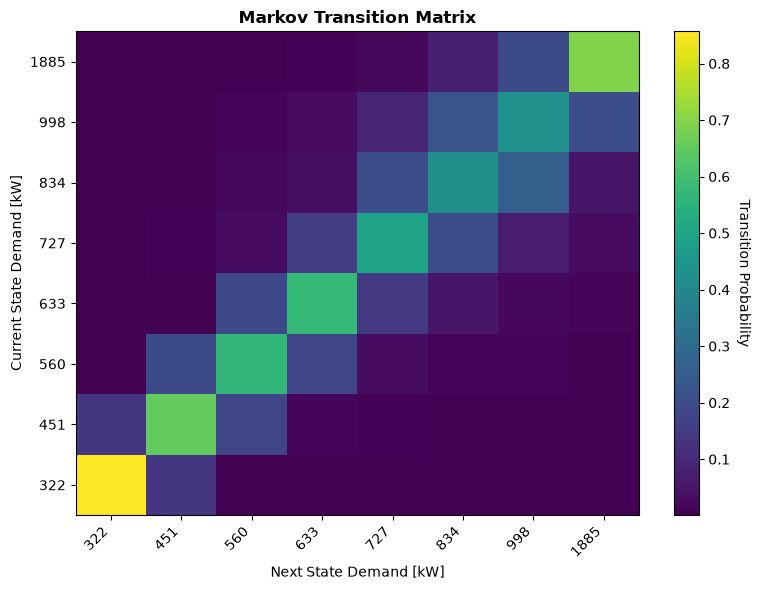

In [8]:
# Manually choose training block and test validation target
train_days = [1, 2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
mc_model, _, _ = benchmarker._get_or_compute_models(train_days, solver_cls=None, horizon_length=1)
plot_markov_matrix(mc_model)
test_day = 4
approaches = augmented_approaches

--- APPROACH A: HAND-PICKED EVALUATION ---
 [Vault] Cache MISS: Solving SDP Bellman matrices (AugmentedHybridSDPSolver)...
| Strategy      | Total Cost [€] | Operating Cost [€] | Switching Cost [€] | Battery Cost [€] | Transient Cost [€] | Term. Switch Cost [€] | Term. SoC Cost [€] | Offline Compute Time [s] | Online Compute Time [s] |
|---------------|----------------|--------------------|--------------------|------------------|--------------------|-----------------------|--------------------|--------------------------|-------------------------|
| MacroFCLocked | 6597.84        | 5665.90            | 712.50             | 60.87            | 114.67             | 37.50                 | 6.40               | 474.89                   | 0.00                    |
| FCLocked      | 7051.75        | 6052.24            | 562.50             | 75.57            | 149.41             | 187.50                | 24.52              | 474.89                   | 0.49                    |
| MacroPolicy   |

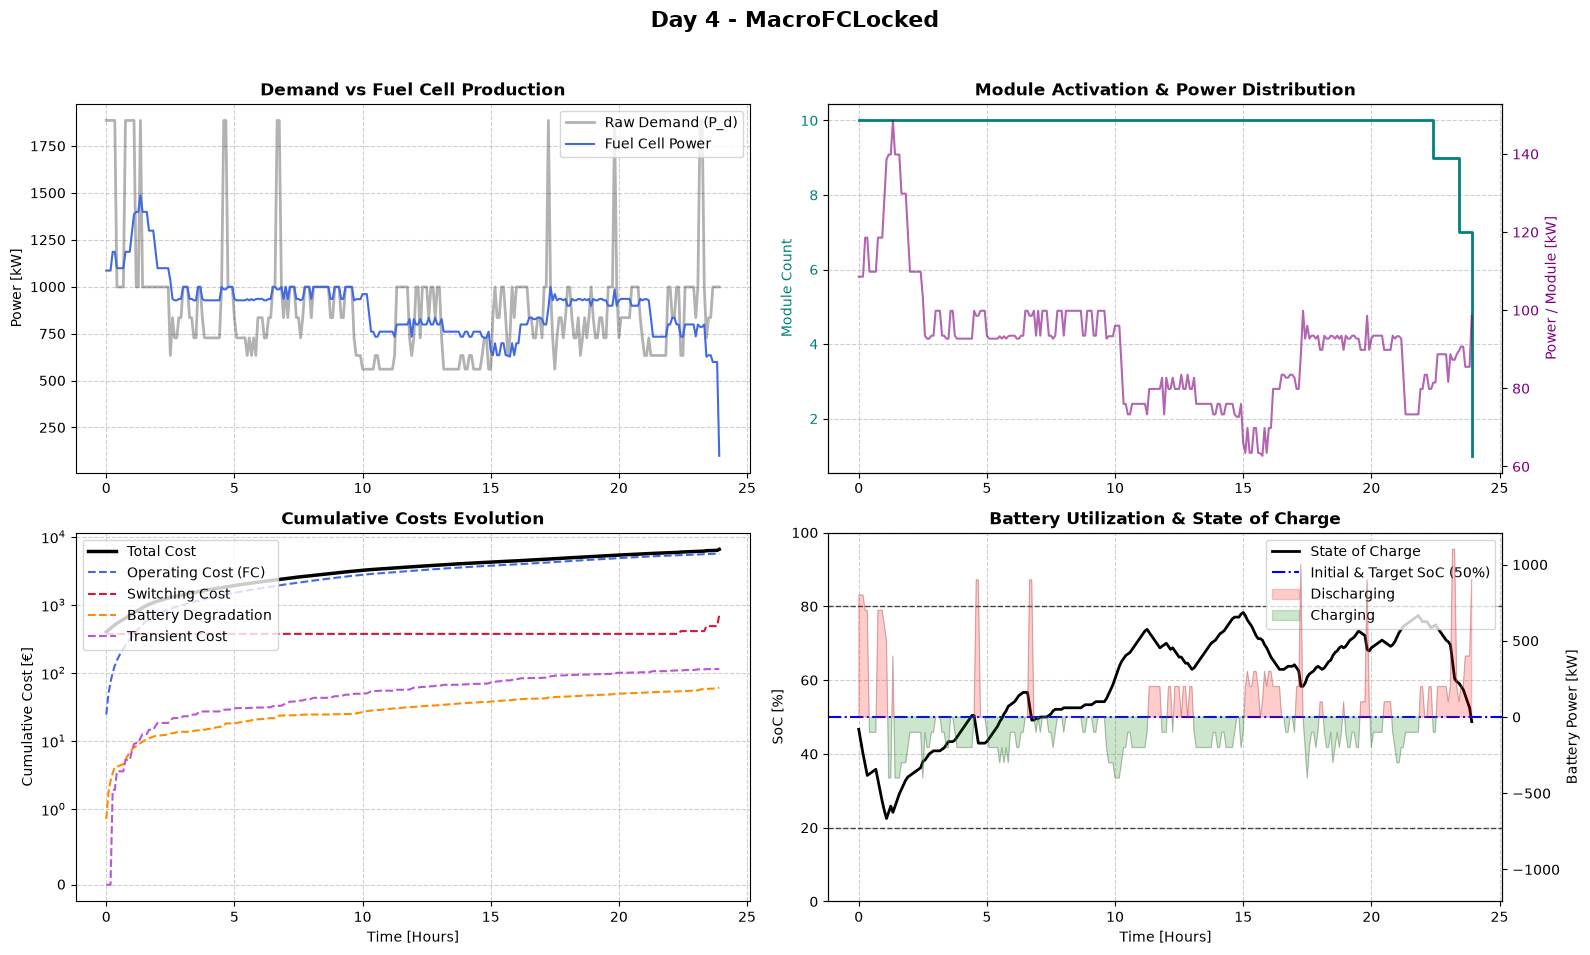

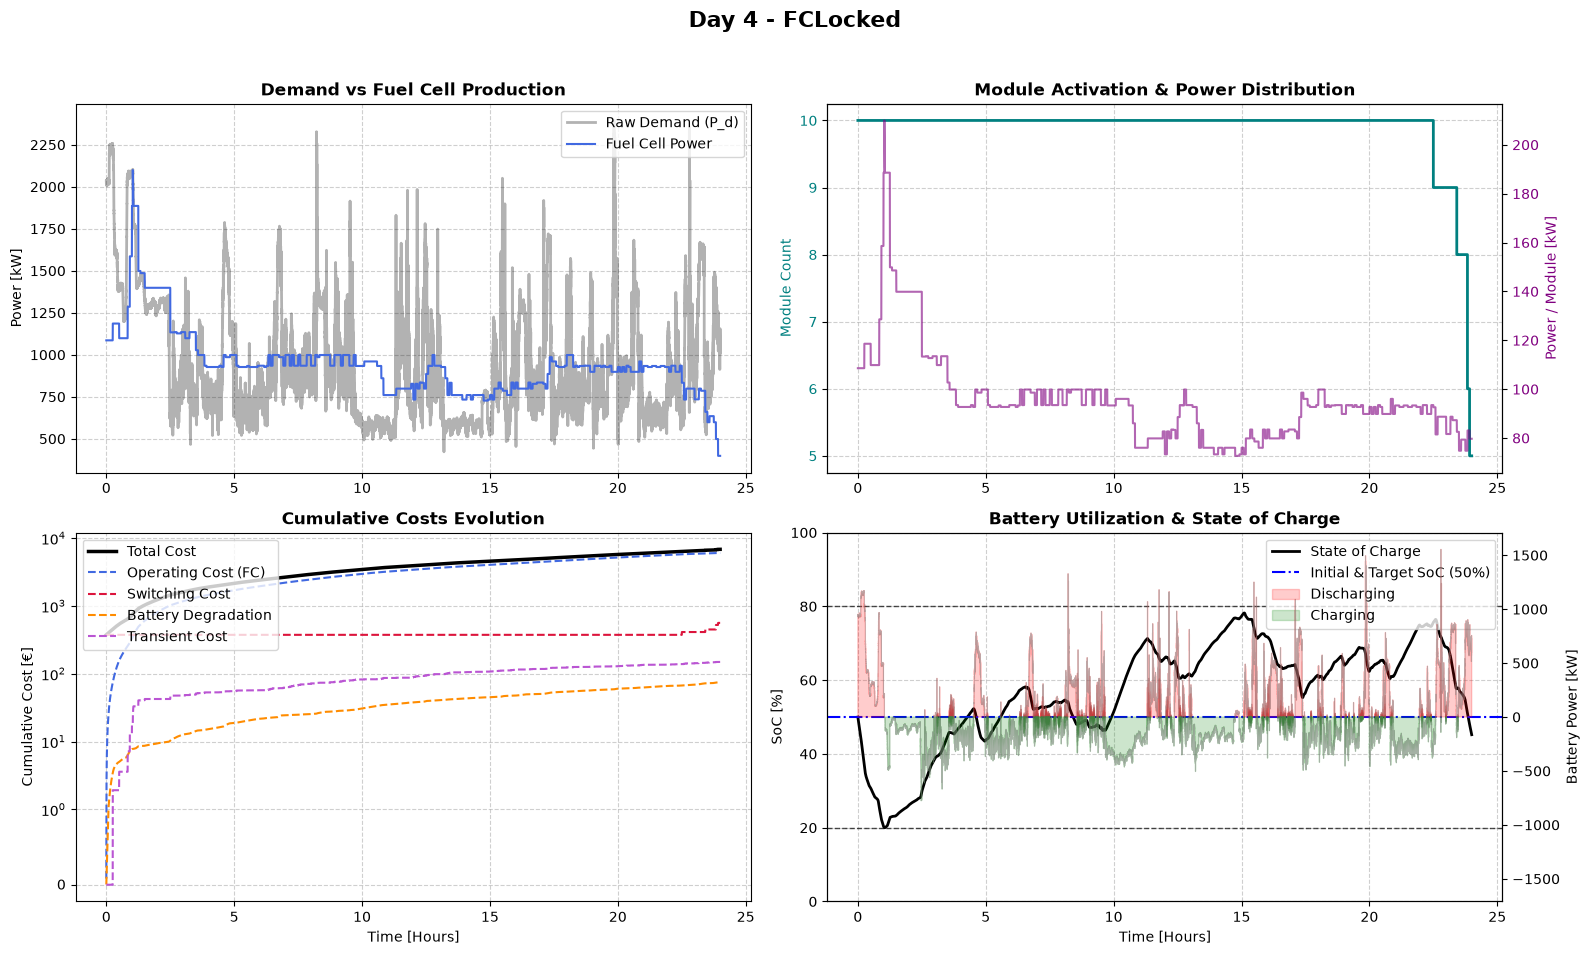

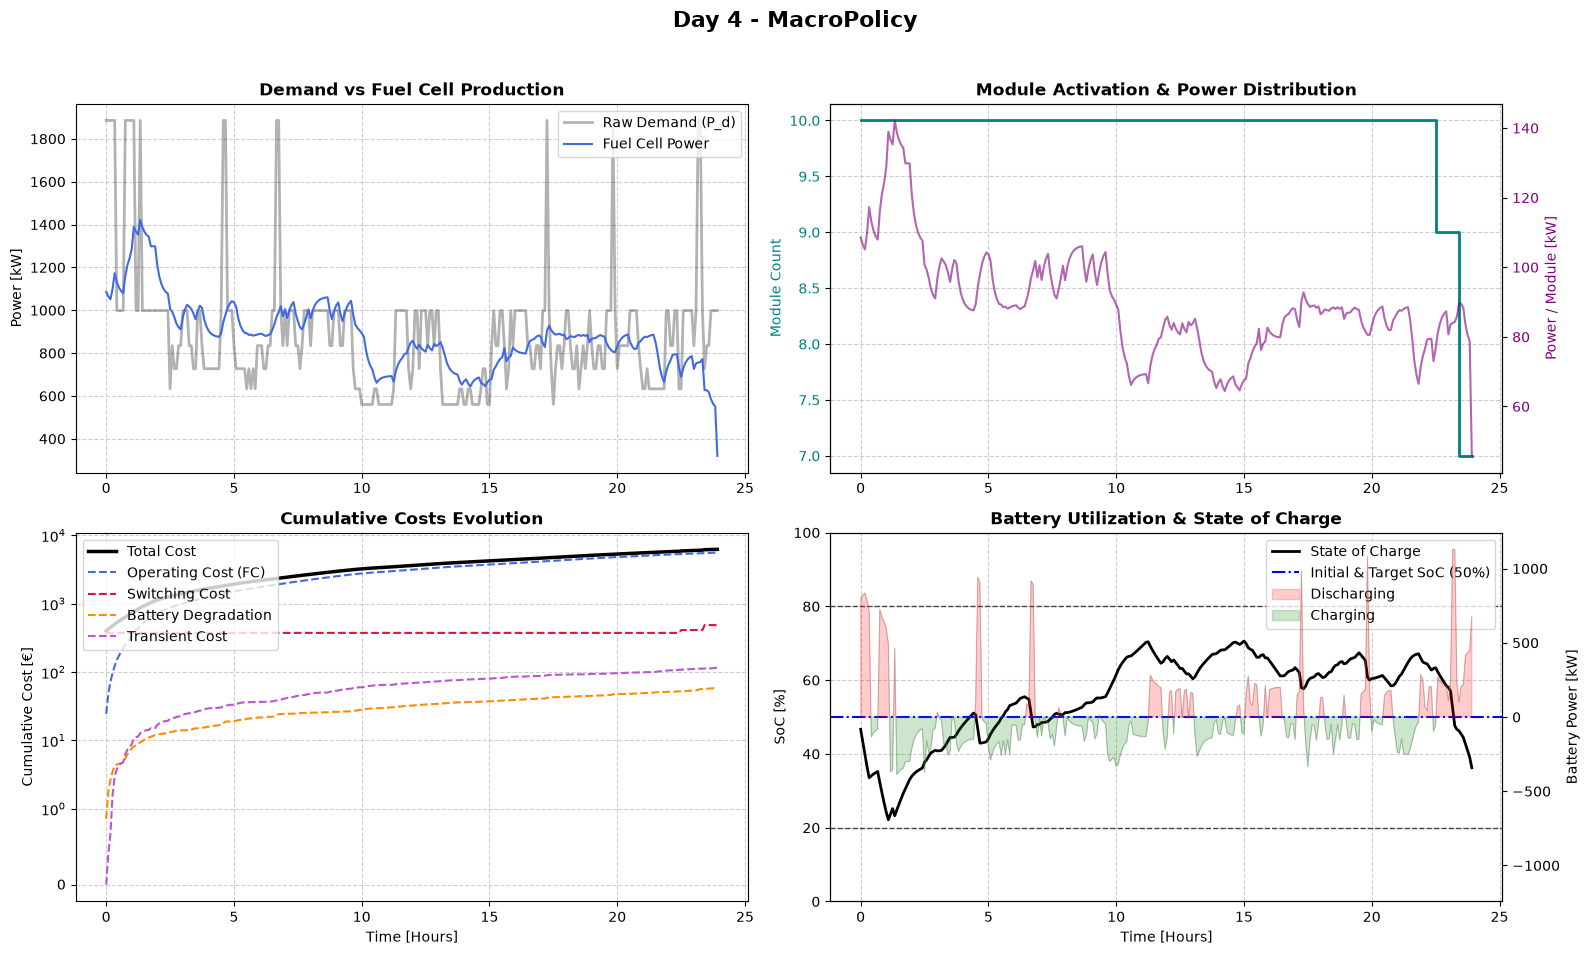

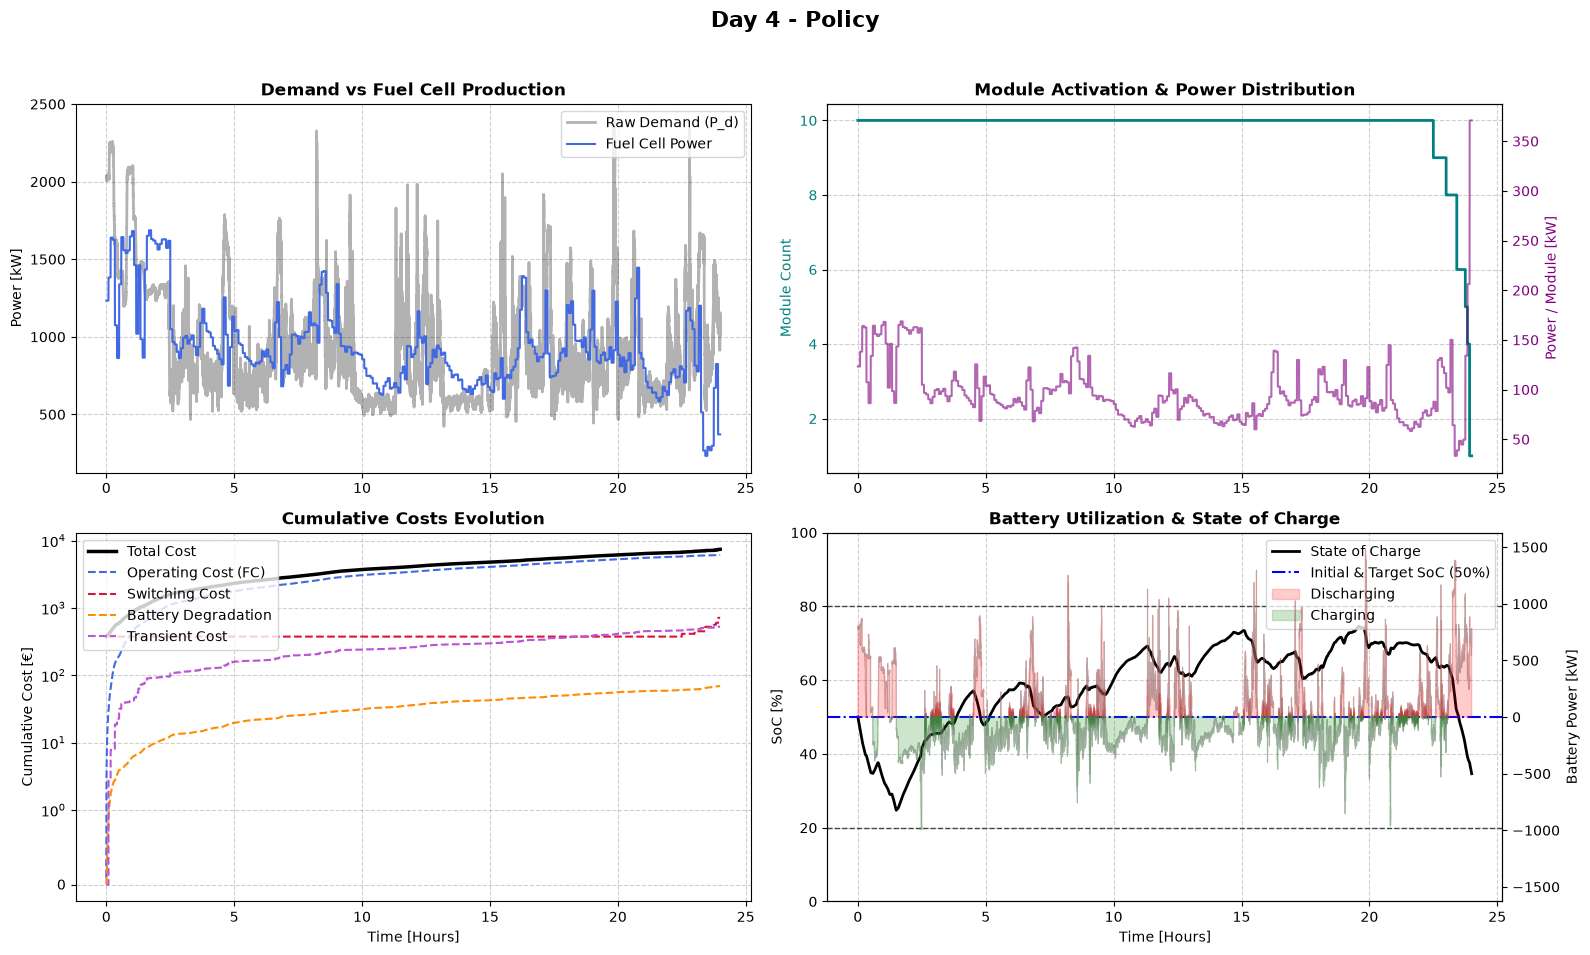

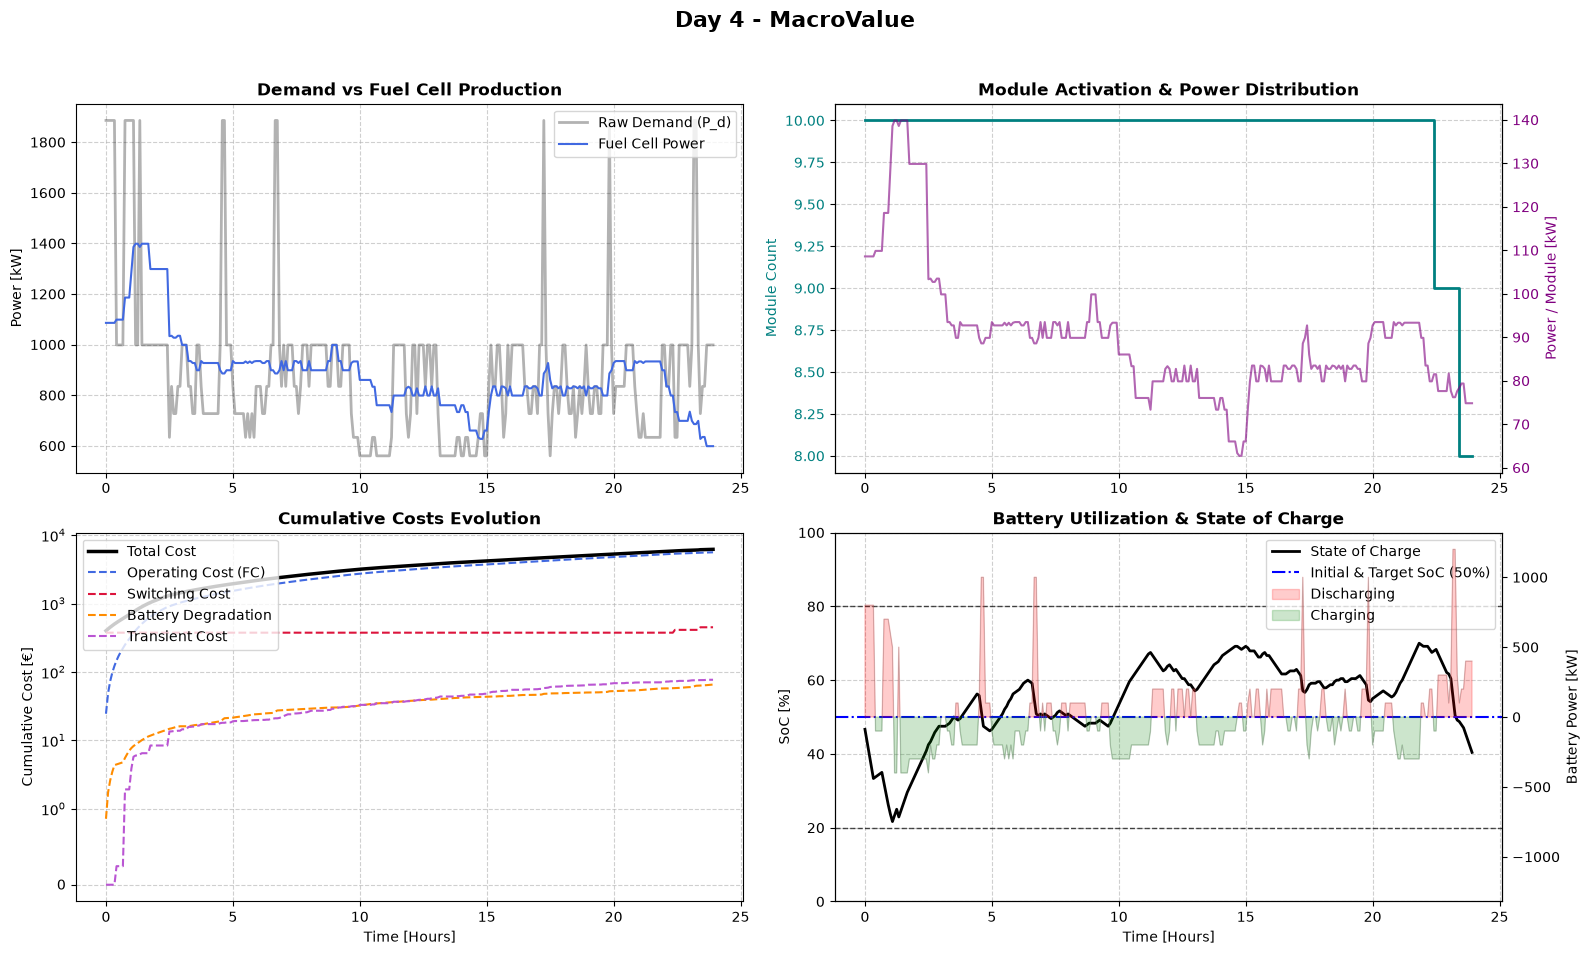

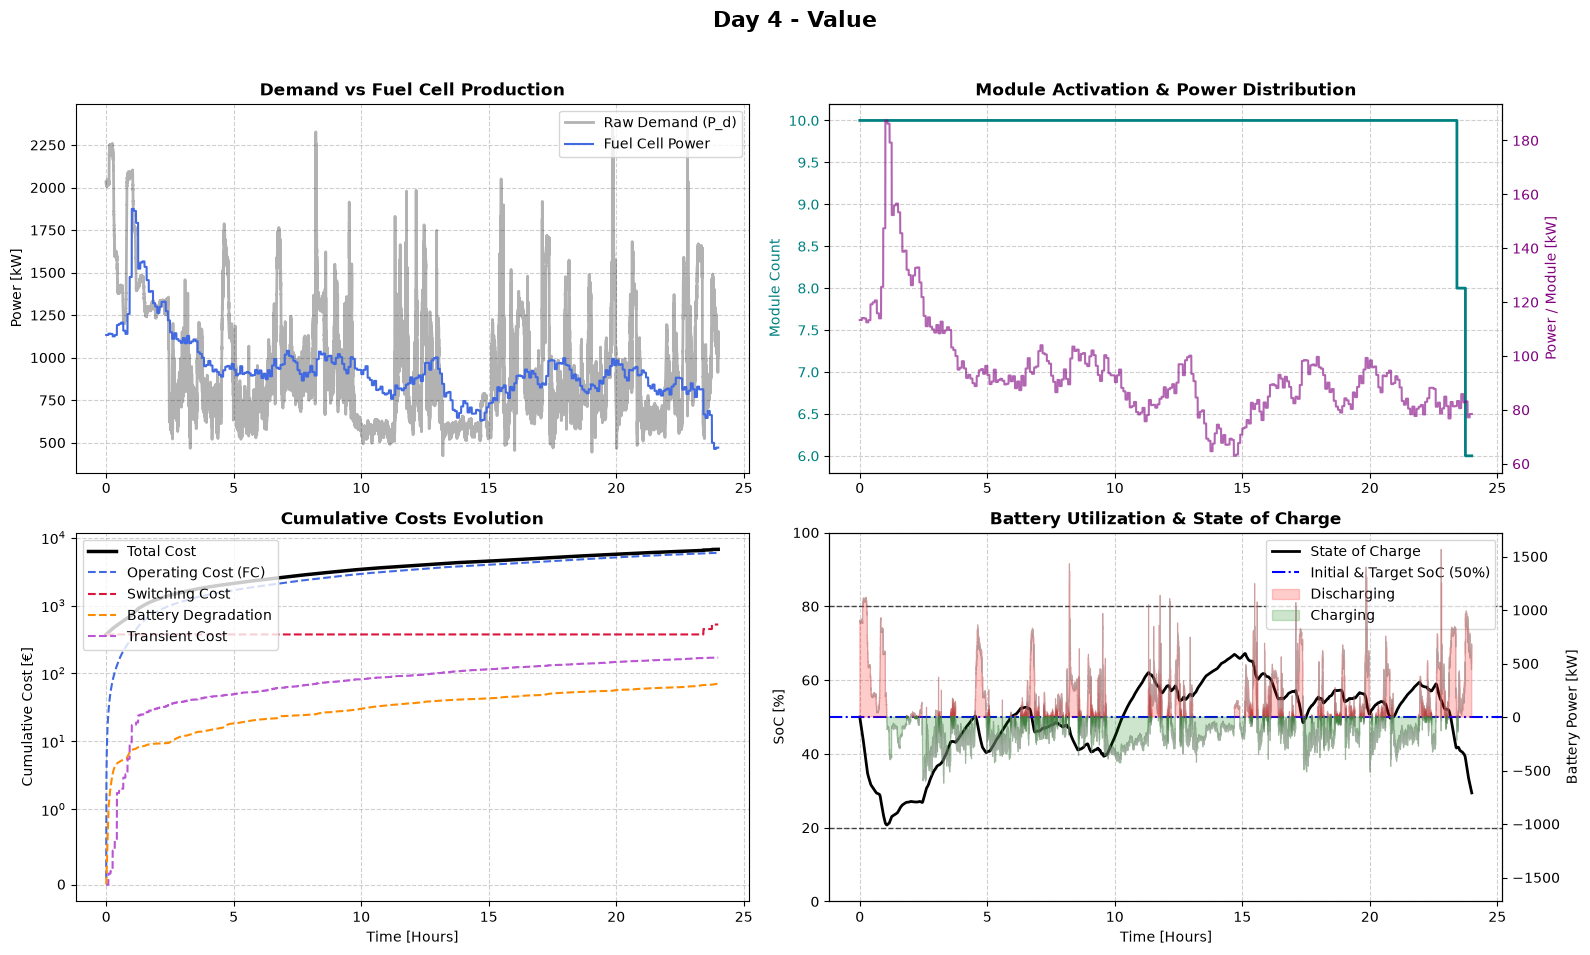

In [9]:
print("--- APPROACH A: HAND-PICKED EVALUATION ---")

report = benchmarker.compare_approaches(approaches, train_days, test_day)
print_markdown_table(report.summary)

for app in approaches:
    plot_simulation_dashboard(report.get_telemetry(app), benchmarker.config, title=f"Day {test_day} - {app}", indiv=False)




--- APPROACH B: LEAVE-ONE-OUT (Discrete Tracking vs Baseline) ---
 [Vault] Cache MISS: Solving SDP Bellman matrices (AugmentedHybridSDPSolver)...
 [Vault] Cache MISS: Solving SDP Bellman matrices (AugmentedHybridSDPSolver)...
 [Vault] Cache MISS: Solving SDP Bellman matrices (AugmentedHybridSDPSolver)...
 [Vault] Cache MISS: Solving SDP Bellman matrices (AugmentedHybridSDPSolver)...
 [Vault] Cache MISS: Solving SDP Bellman matrices (AugmentedHybridSDPSolver)...
 [Vault] Cache MISS: Solving SDP Bellman matrices (AugmentedHybridSDPSolver)...
 [Vault] Cache MISS: Solving SDP Bellman matrices (AugmentedHybridSDPSolver)...
 [Vault] Cache MISS: Solving SDP Bellman matrices (AugmentedHybridSDPSolver)...
 [Vault] Cache MISS: Solving SDP Bellman matrices (AugmentedHybridSDPSolver)...
 [Vault] Cache MISS: Solving SDP Bellman matrices (AugmentedHybridSDPSolver)...
 [Vault] Cache MISS: Solving SDP Bellman matrices (AugmentedHybridSDPSolver)...
 [Vault] Cache MISS: Solving SDP Bellman matrices (Au

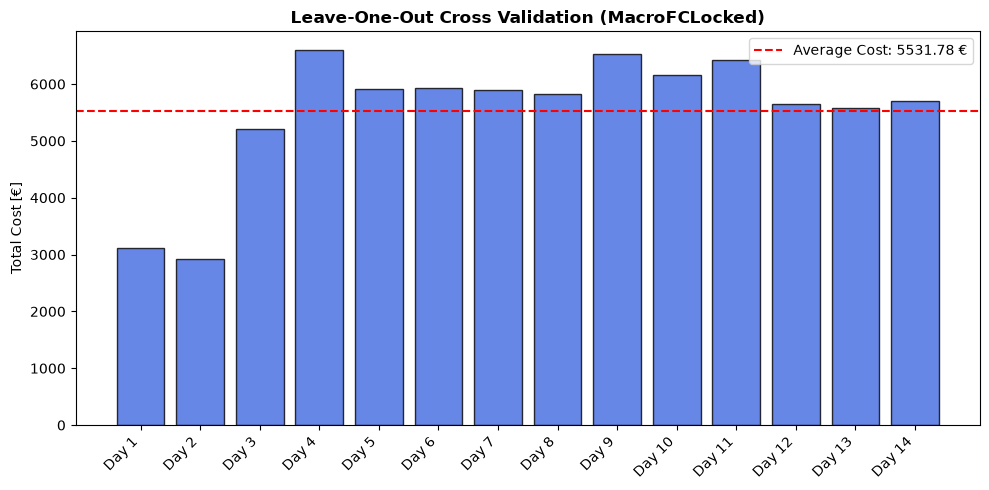

| Strategy | Total Cost [€] | Operating Cost [€] | Switching Cost [€] | Battery Cost [€] | Transient Cost [€] | Term. Switch Cost [€] | Term. SoC Cost [€] | Offline Compute Time [s] | Online Compute Time [s] |
|----------|----------------|--------------------|--------------------|------------------|--------------------|-----------------------|--------------------|--------------------------|-------------------------|
| Day 1    | 3120.35        | 2607.23            | 562.50             | 9.87             | 37.66              | 37.50                 | -134.41            | 470.35                   | 0.00                    |
| Day 2    | 2914.04        | 2442.15            | 450.00             | 12.04            | 30.86              | 75.00                 | -96.01             | 433.80                   | 0.00                    |
| Day 3    | 5210.10        | 4274.83            | 337.50             | 23.33            | 85.46              | 337.50                | 151.48             | 409

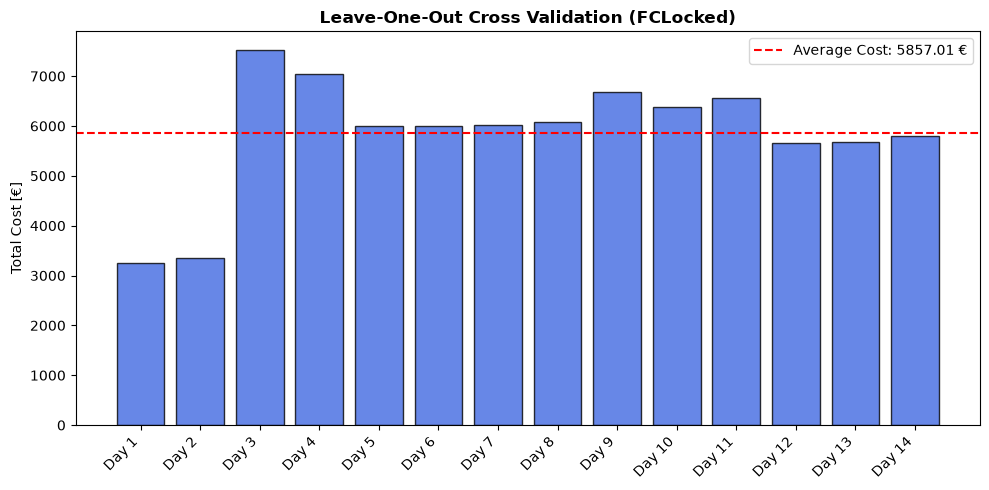

| Strategy | Total Cost [€] | Operating Cost [€] | Switching Cost [€] | Battery Cost [€] | Transient Cost [€] | Term. Switch Cost [€] | Term. SoC Cost [€] | Offline Compute Time [s] | Online Compute Time [s] |
|----------|----------------|--------------------|--------------------|------------------|--------------------|-----------------------|--------------------|--------------------------|-------------------------|
| Day 1    | 3256.97        | 2584.81            | 487.50             | 16.06            | 173.49             | 112.50                | -117.40            | 470.35                   | 0.28                    |
| Day 2    | 3348.15        | 2608.44            | 600.00             | 20.10            | 136.01             | 75.00                 | -91.41             | 433.80                   | 0.28                    |
| Day 3    | 7522.28        | 5301.99            | 337.50             | 29.38            | 1362.28            | 337.50                | 153.64             | 409

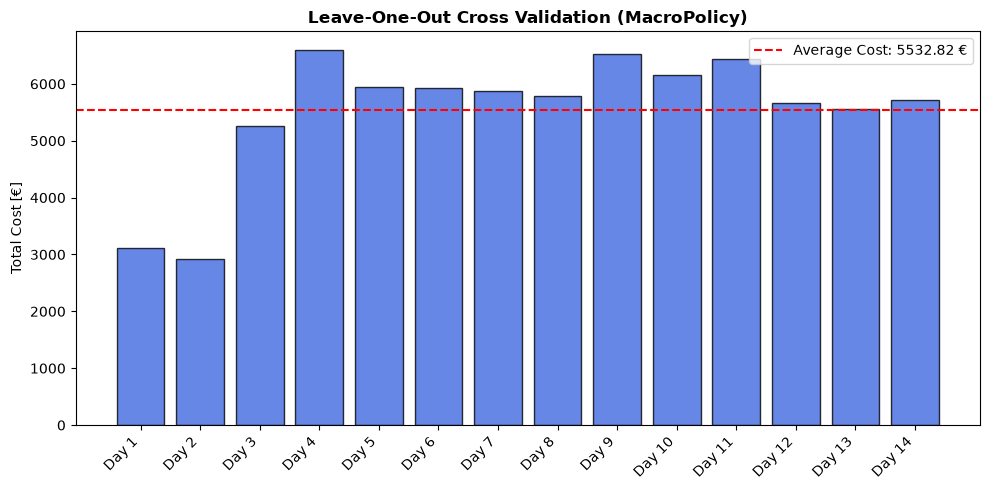

| Strategy | Total Cost [€] | Operating Cost [€] | Switching Cost [€] | Battery Cost [€] | Transient Cost [€] | Term. Switch Cost [€] | Term. SoC Cost [€] | Offline Compute Time [s] | Online Compute Time [s] |
|----------|----------------|--------------------|--------------------|------------------|--------------------|-----------------------|--------------------|--------------------------|-------------------------|
| Day 1    | 3112.18        | 2579.26            | 525.00             | 12.67            | 34.13              | 75.00                 | -113.88            | 470.35                   | 0.00                    |
| Day 2    | 2917.85        | 2440.23            | 450.00             | 12.19            | 38.15              | 75.00                 | -97.72             | 433.80                   | 0.00                    |
| Day 3    | 5265.14        | 4324.52            | 337.50             | 23.46            | 88.54              | 337.50                | 153.61             | 409

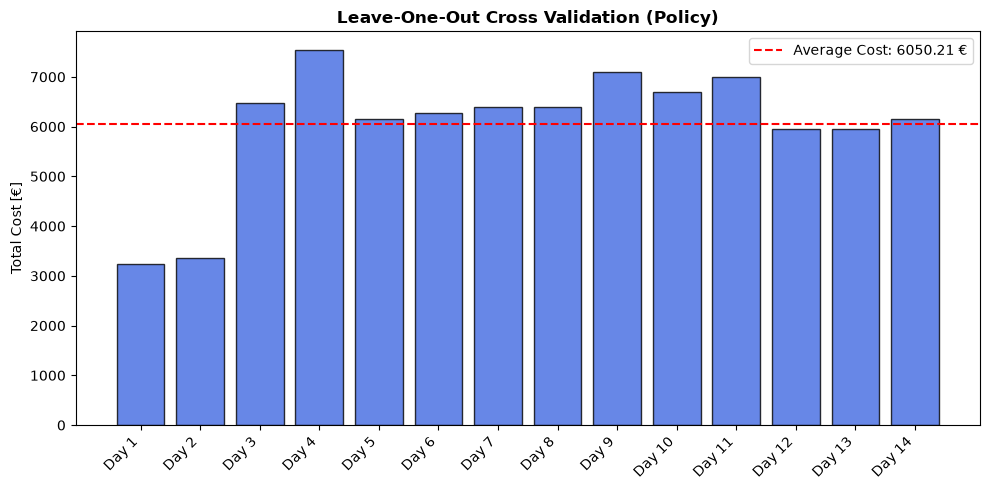

| Strategy | Total Cost [€] | Operating Cost [€] | Switching Cost [€] | Battery Cost [€] | Transient Cost [€] | Term. Switch Cost [€] | Term. SoC Cost [€] | Offline Compute Time [s] | Online Compute Time [s] |
|----------|----------------|--------------------|--------------------|------------------|--------------------|-----------------------|--------------------|--------------------------|-------------------------|
| Day 1    | 3241.46        | 2548.59            | 525.00             | 17.76            | 167.59             | 75.00                 | -92.48             | 470.35                   | 0.30                    |
| Day 2    | 3367.53        | 2600.96            | 600.00             | 18.90            | 163.51             | 75.00                 | -90.83             | 433.80                   | 0.27                    |
| Day 3    | 6481.43        | 5369.29            | 337.50             | 28.41            | 255.13             | 337.50                | 153.60             | 409

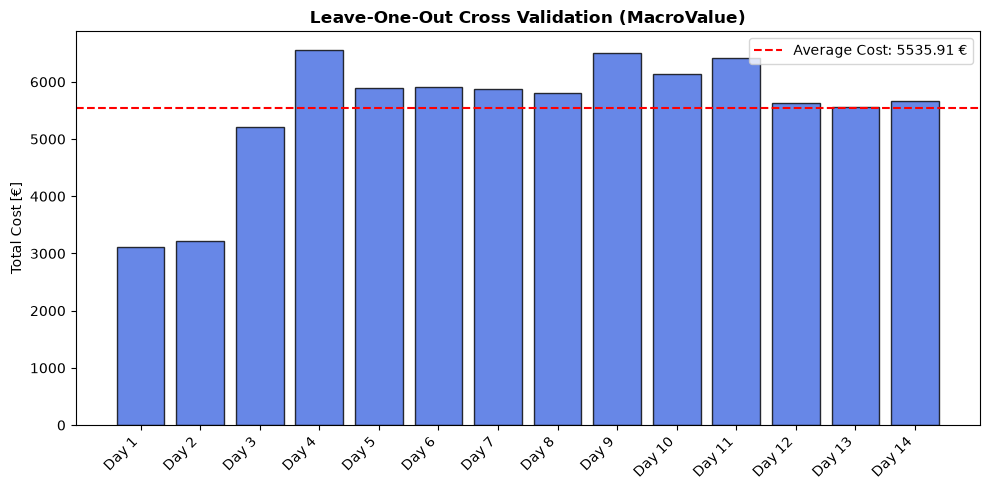

| Strategy | Total Cost [€] | Operating Cost [€] | Switching Cost [€] | Battery Cost [€] | Transient Cost [€] | Term. Switch Cost [€] | Term. SoC Cost [€] | Offline Compute Time [s] | Online Compute Time [s] |
|----------|----------------|--------------------|--------------------|------------------|--------------------|-----------------------|--------------------|--------------------------|-------------------------|
| Day 1    | 3109.75        | 2606.18            | 525.00             | 11.83            | 26.16              | 75.00                 | -134.41            | 470.35                   | 0.02                    |
| Day 2    | 3221.96        | 2609.80            | 562.50             | 12.15            | 27.41              | 112.50                | -102.41            | 433.80                   | 0.02                    |
| Day 3    | 5210.46        | 4275.31            | 337.50             | 23.33            | 85.34              | 337.50                | 151.48             | 409

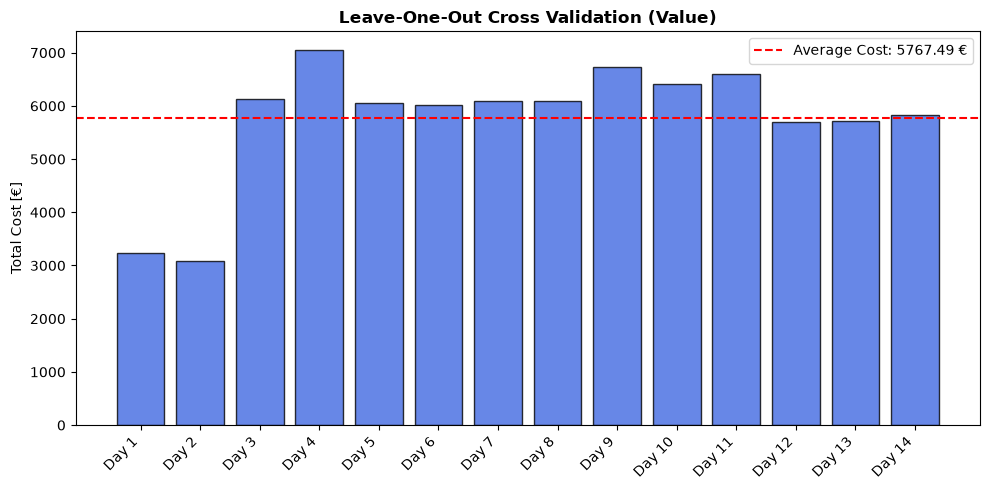

| Strategy | Total Cost [€] | Operating Cost [€] | Switching Cost [€] | Battery Cost [€] | Transient Cost [€] | Term. Switch Cost [€] | Term. SoC Cost [€] | Offline Compute Time [s] | Online Compute Time [s] |
|----------|----------------|--------------------|--------------------|------------------|--------------------|-----------------------|--------------------|--------------------------|-------------------------|
| Day 1    | 3233.33        | 2563.79            | 562.50             | 16.61            | 155.36             | 37.50                 | -102.43            | 470.35                   | 0.30                    |
| Day 2    | 3088.91        | 2465.55            | 450.00             | 18.60            | 166.10             | 75.00                 | -86.33             | 433.80                   | 0.30                    |
| Day 3    | 6138.35        | 4827.30            | 450.00             | 29.27            | 230.61             | 450.00                | 151.16             | 409

In [10]:
print("\n--- APPROACH B: LEAVE-ONE-OUT (Discrete Tracking vs Baseline) ---")

# Note: Running LOO on all 5 approaches might take a couple of minutes due to 4D solves.
# Let's compare the main engineering deployable hybrid against the legacy baseline.

for app in approaches:
# for app in ["Value"]:
    report = benchmarker.run_leave_one_out(approaches[app])
    plot_benchmarker_results(report.summary, title=f"Leave-One-Out Cross Validation ({app})", plot_type='bar')
    print_markdown_table(report.summary)



In [ ]:
print("\n--- APPROACH C: FORWARD CHAINING (Learning Curve) ---")
# Evaluate how the policy improves as the agent gathers chronological data
# Using the Lookahead Optimum to see the absolute theoretical ceiling of the ship's capabilities

for app in approaches:
# for app in ["Value"]:
    report = benchmarker.run_forward_chaining(approaches[app])
    plot_benchmarker_results(report.summary, title=f"Forward Chaining Learning Curve ({app})", plot_type='line')
    print_markdown_table(report.summary)


--- APPROACH C: FORWARD CHAINING (Learning Curve) ---
 [Vault] Cache MISS: Training Markov Chain for days [1]...
 [Vault] Cache MISS: Solving SDP Bellman matrices (AugmentedHybridSDPSolver)...
 [Vault] Cache MISS: Training Markov Chain for days [1, 2]...
 [Vault] Cache MISS: Solving SDP Bellman matrices (AugmentedHybridSDPSolver)...
 [Vault] Cache MISS: Training Markov Chain for days [1, 2, 3]...
 [Vault] Cache MISS: Solving SDP Bellman matrices (AugmentedHybridSDPSolver)...
